In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

df = pd.read_csv('../data/Flight_delay.csv')

os.makedirs('../results/plots', exist_ok=True)

df.head()
df.shape
df.columns
df.info()
df.isnull().sum().sort_values(ascending=False) 

<class 'pandas.DataFrame'>
RangeIndex: 484551 entries, 0 to 484550
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   DayOfWeek          484551 non-null  int64
 1   Date               484551 non-null  str  
 2   DepTime            484551 non-null  int64
 3   ArrTime            484551 non-null  int64
 4   CRSArrTime         484551 non-null  int64
 5   UniqueCarrier      484551 non-null  str  
 6   Airline            484551 non-null  str  
 7   FlightNum          484551 non-null  int64
 8   TailNum            484551 non-null  str  
 9   ActualElapsedTime  484551 non-null  int64
 10  CRSElapsedTime     484551 non-null  int64
 11  AirTime            484551 non-null  int64
 12  ArrDelay           484551 non-null  int64
 13  DepDelay           484551 non-null  int64
 14  Origin             484551 non-null  str  
 15  Org_Airport        483374 non-null  str  
 16  Dest               484551 non-null  str  
 17  De

Dest_Airport         1479
Org_Airport          1177
DepTime                 0
Date                    0
DayOfWeek               0
UniqueCarrier           0
Airline                 0
FlightNum               0
TailNum                 0
ActualElapsedTime       0
CRSElapsedTime          0
ArrTime                 0
CRSArrTime              0
ArrDelay                0
AirTime                 0
Origin                  0
DepDelay                0
Dest                    0
Distance                0
TaxiIn                  0
TaxiOut                 0
Cancelled               0
CancellationCode        0
Diverted                0
CarrierDelay            0
WeatherDelay            0
NASDelay                0
SecurityDelay           0
LateAircraftDelay       0
dtype: int64

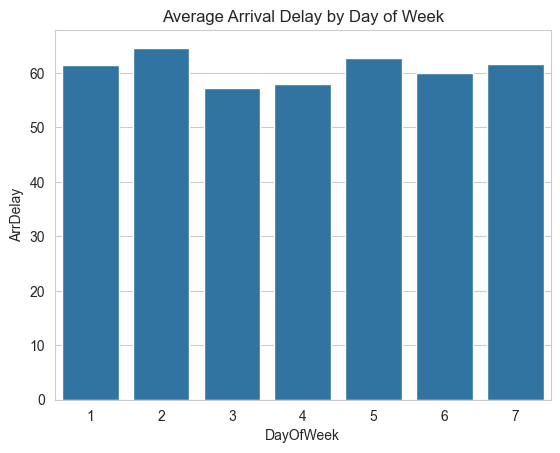

In [4]:
delay_by_day = df.groupby('DayOfWeek')['ArrDelay'].mean().reset_index()

sns.barplot(data=delay_by_day, x='DayOfWeek', y='ArrDelay')
plt.title("Average Arrival Delay by Day of Week")
plt.savefig('../results/plots/delay_by_day.png')
plt.show()


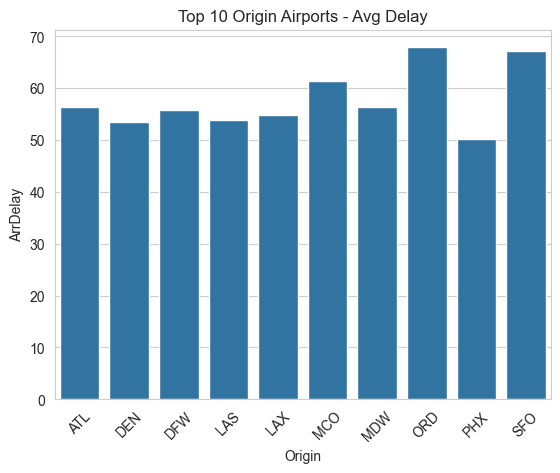

In [5]:
top_origins = df['Origin'].value_counts().head(10).index
origin_delay = df[df['Origin'].isin(top_origins)] \
    .groupby('Origin')['ArrDelay'].mean().reset_index()

sns.barplot(data=origin_delay, x='Origin', y='ArrDelay')
plt.xticks(rotation=45)
plt.title("Top 10 Origin Airports - Avg Delay")
plt.savefig('../results/plots/origin_delay.png')
plt.show()

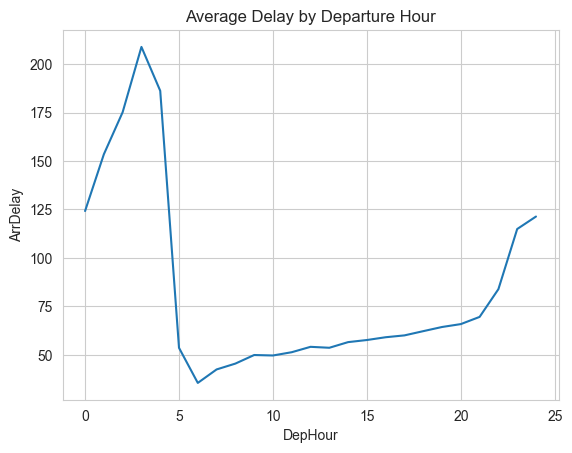

In [6]:
df['DepHour'] = df['DepTime'] // 100

delay_by_hour = df.groupby('DepHour')['ArrDelay'].mean().reset_index()

sns.lineplot(data=delay_by_hour, x='DepHour', y='ArrDelay')
plt.title("Average Delay by Departure Hour")
plt.savefig('../results/plots/delay_by_hour.png')
plt.show()

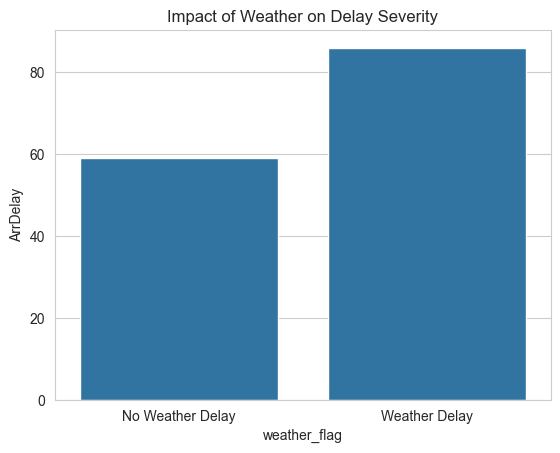

In [7]:
df['weather_flag'] = (df['WeatherDelay'] > 0).astype(int)

weather_impact = df.groupby('weather_flag')['ArrDelay'].mean().reset_index()

sns.barplot(data=weather_impact,
            x='weather_flag',
            y='ArrDelay')

plt.xticks([0,1], ['No Weather Delay', 'Weather Delay'])
plt.title("Impact of Weather on Delay Severity")
plt.savefig('../results/plots/weather_impact.png')
plt.show()

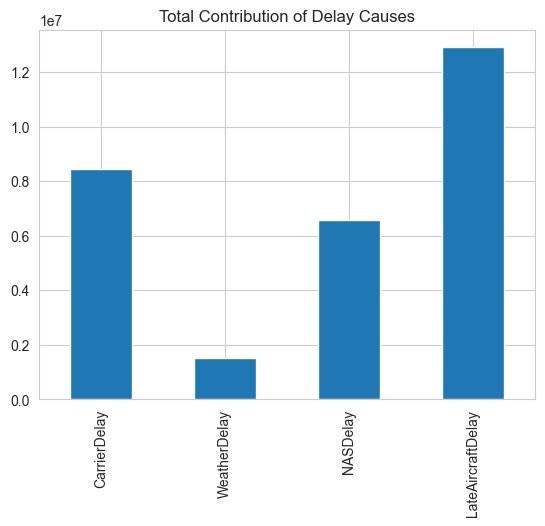

In [8]:
delay_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'LateAircraftDelay']

df[delay_cols].sum().plot(kind='bar')
plt.title("Total Contribution of Delay Causes")
plt.savefig('../results/plots/delay_causes.png')
plt.show()

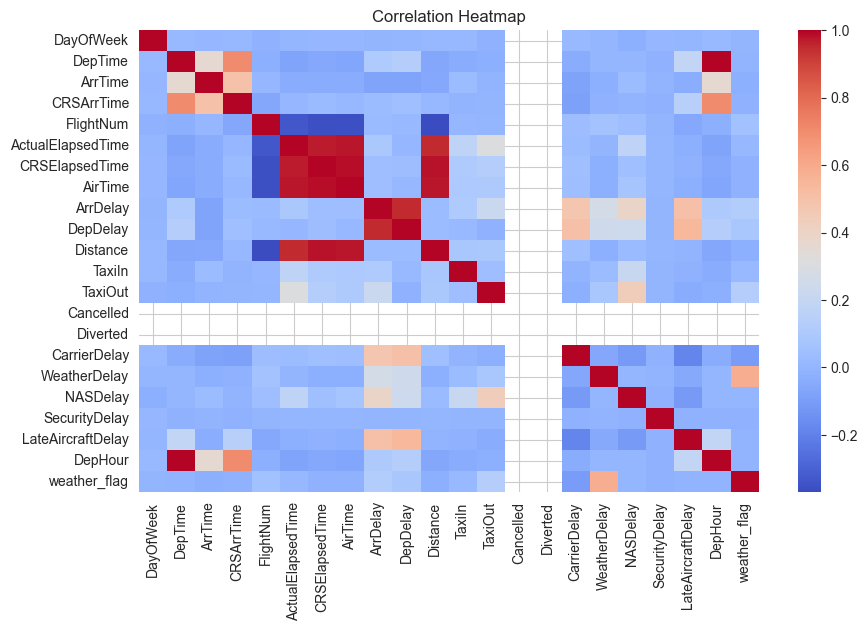

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig('../results/plots/correlation.png')
plt.show()

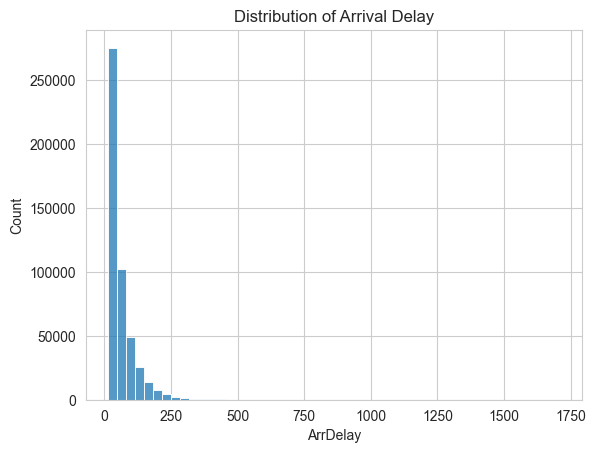

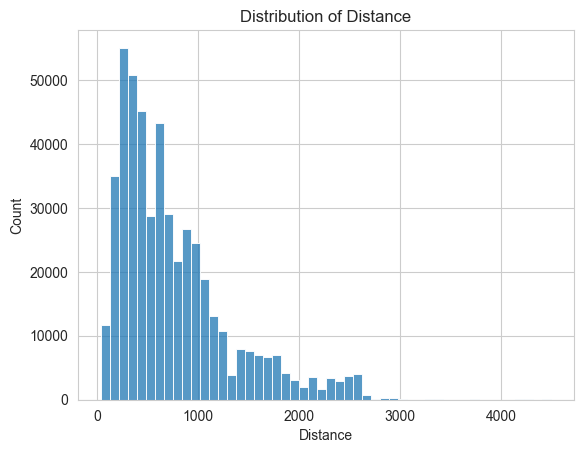

In [10]:
sns.histplot(df['ArrDelay'], bins=50)
plt.title("Distribution of Arrival Delay")
plt.savefig('../results/plots/arrdelay_dist.png')
plt.show()

sns.histplot(df['Distance'], bins=50)
plt.title("Distribution of Distance")
plt.savefig('../results/plots/distance_dist.png')
plt.show()